# EfficientNetB0 — Cross-Database Deepfake Detection Experiment

**Research question:** Does an RGB-appearance detector trained on one deepfake dataset generalize to others?

**Architecture (aligned with main notebook `the_modles_fixed_new` §8):**
- EfficientNetB0 (ImageNet weights) → GAP → Dense head → sigmoid
- Stage 1: backbone frozen, train head only
- Stage 2: unfreeze top 30% of backbone, fine-tune end-to-end at low LR
- Augmentation: flips + mild brightness/contrast + pad-then-crop (real random crop, no `random_hue`)

**Experiment matrix:** 5 training runs × 5 test sets = **25 evaluations**

| Train ↓ \ Test → | OpenForensics | CustomWar | CelebDF | CiFake | ALL |
|------------------|---------------|-----------|---------|--------|-----|
| OpenForensics    | ✓ within      | ✗ cross   | ✗ cross | ✗ cross | mix |
| CustomWar        | ✗ cross       | ✓ within  | ✗ cross | ✗ cross | mix |
| CelebDF          | ✗ cross       | ✗ cross   | ✓ within | ✗ cross | mix |
| CiFake           | ✗ cross       | ✗ cross   | ✗ cross  | ✓ within | mix |
| ALL              | mix           | mix       | mix     | mix    | ✓ within |

**Databases:** OpenForensics · CustomWar · CelebDF · CiFake (CiFake uses the 80/20 split from `cifake_split/`)

In [1]:
# =================== CELL 1: SETUP ===================
import os
import gc
import glob
import random
import pickle
import numpy as np
import tensorflow as tf
import mimetypes
from datetime import datetime

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/usr/lib/nvidia-cuda-toolkit'
tf.config.optimizer.set_jit(False)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU memory growth enabled')
    except RuntimeError as e:
        print(e)

tf.keras.backend.clear_session()
print(f'Setup complete — TensorFlow {tf.__version__}')

2026-05-05 11:03:37.918342: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU memory growth enabled
Setup complete — TensorFlow 2.20.0


In [2]:
# =================== CELL 2: PATHS & TENSORBOARD CONFIG ===================

GDRIVE_PATH      = os.path.expanduser('~/RealEyes/gdrive')
DATASET_ROOT     = os.path.join(GDRIVE_PATH, 'data_set_split')      # CustomWar split
DATASETS_DIR     = os.path.expanduser('~/RealEyes/RealEyes/datasets')
CELEBDF_DIR      = os.path.join(DATASETS_DIR, 'celebdf_v2')
CIFAKE_SPLIT_DIR = os.path.join(DATASETS_DIR, 'cifake_split')      # 80/20 split from main notebook

MODEL_NAME            = 'efficientnet'
EXPERIMENT_MODELS_DIR = os.path.join(GDRIVE_PATH, 'deepfake_image_project', 'models', 'RealEyes_experiment')
MODEL_DIR             = os.path.join(EXPERIMENT_MODELS_DIR, MODEL_NAME)
os.makedirs(MODEL_DIR, exist_ok=True)

TB_LOG_ROOT = os.path.expanduser('~/RealEyes/tensorboard_logs')
os.makedirs(TB_LOG_ROOT, exist_ok=True)


def get_tb_log_dir(train_db_name, suffix='train'):
    ts = datetime.now().strftime('%Y%m%d_%H%M')
    return os.path.join(TB_LOG_ROOT, MODEL_NAME, f'{suffix}_{train_db_name}', ts)


def log_eval_to_tb(train_db_name, test_db_name, metrics: dict, step=0):
    log_dir = os.path.join(
        TB_LOG_ROOT, MODEL_NAME, 'cross_db_eval',
        f'train_{train_db_name}__test_{test_db_name}'
    )
    writer = tf.summary.create_file_writer(log_dir)
    with writer.as_default():
        for name, value in metrics.items():
            tf.summary.scalar(name, float(value), step=step)
    writer.flush()


print('Paths ready')
print(f'  MODEL_DIR        : {MODEL_DIR}')
print(f'  CIFAKE_SPLIT_DIR : {CIFAKE_SPLIT_DIR}')
print(f'  TB_LOG_ROOT      : {TB_LOG_ROOT}')
print()
print('View TensorBoard:')
print(f'  [server ] tensorboard --logdir {TB_LOG_ROOT} --port 6006 --bind_all')
print( '  [local  ] ssh -L 6006:localhost:6006 <user>@<server_ip>')
print( '  [browser] http://localhost:6006')

Paths ready
  MODEL_DIR        : /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet
  CIFAKE_SPLIT_DIR : /home/sceuser/RealEyes/RealEyes/datasets/cifake_split
  TB_LOG_ROOT      : /home/sceuser/RealEyes/tensorboard_logs

View TensorBoard:
  [server ] tensorboard --logdir /home/sceuser/RealEyes/tensorboard_logs --port 6006 --bind_all
  [local  ] ssh -L 6006:localhost:6006 <user>@<server_ip>
  [browser] http://localhost:6006


In [3]:
# =================== CELL 3: DATABASE DEFINITIONS ===================
# CiFake now uses the 80/20 split (cifake_split/{train,val,test}) created
# by the main notebook's Section 3.3 — so it has a real held-out test set.

DATABASES = {}


def _try_add(name, paths):
    missing = [k for k, v in paths.items() if not os.path.isdir(v)]
    if missing:
        print(f'  {name}: missing splits {missing} — skipped')
        return
    DATABASES[name] = paths
    print(f'  {name}')


print('Scanning databases...')

_try_add('OpenForensics', {
    'train': os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Train'),
    'val':   os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Validation'),
    'test':  os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Test'),
})
_try_add('CustomWar', {
    'train': os.path.join(DATASET_ROOT, 'train'),
    'val':   os.path.join(DATASET_ROOT, 'val'),
    'test':  os.path.join(DATASET_ROOT, 'test'),
})
_try_add('CelebDF', {
    'train': os.path.join(CELEBDF_DIR, 'train'),
    'val':   os.path.join(CELEBDF_DIR, 'val'),
    'test':  os.path.join(CELEBDF_DIR, 'test'),
})
_try_add('CiFake', {
    'train': os.path.join(CIFAKE_SPLIT_DIR, 'train'),
    'val':   os.path.join(CIFAKE_SPLIT_DIR, 'val'),
    'test':  os.path.join(CIFAKE_SPLIT_DIR, 'test'),
})

print(f'\nActive databases: {list(DATABASES.keys())}')

Scanning databases...
  OpenForensics
  CustomWar
  CelebDF
  CiFake: missing splits ['train', 'val', 'test'] — skipped

Active databases: ['OpenForensics', 'CustomWar', 'CelebDF']


In [4]:
# =================== CELL 4: DATA LOADING HELPERS ===================
# load_split() supports both real DB names and the special 'ALL' name
# (concatenation of every database's split).

def load_dataset_images(dataset_path, max_images=None):
    valid_ext = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}
    image_paths, labels, skipped = [], [], 0

    for folder in sorted(os.listdir(dataset_path)):
        fpath = os.path.join(dataset_path, folder)
        if not os.path.isdir(fpath):
            continue
        fu = folder.upper()
        if fu == 'FAKE':
            label = 1
        elif fu == 'REAL':
            label = 0
        else:
            print(f'  Unknown folder "{folder}" in {dataset_path} — skipped')
            continue

        collected = []
        for root, _, files in os.walk(fpath):
            for fname in files:
                if os.path.splitext(fname)[1].lower() not in valid_ext:
                    skipped += 1
                    continue
                collected.append(os.path.join(root, fname))
        if max_images:
            collected = collected[:max_images]
        image_paths.extend(collected)
        labels.extend([label] * len(collected))

    if skipped:
        print(f'  {skipped} non-image files skipped')
    return np.array(image_paths), np.array(labels)


def load_split(target_name, split='train'):
    """Load (paths, labels) for a target.

    target_name: a real DB key in DATABASES, OR the literal string 'ALL'
                 which concatenates every database's split.
    """
    if target_name == 'ALL':
        all_paths, all_labels = [], []
        for db_name in DATABASES:
            paths, labels = load_dataset_images(DATABASES[db_name][split])
            all_paths.extend(paths)
            all_labels.extend(labels)
        paths  = np.array(all_paths)
        labels = np.array(all_labels)
    else:
        paths, labels = load_dataset_images(DATABASES[target_name][split])

    n_real = int(np.sum(labels == 0))
    n_fake = int(np.sum(labels == 1))
    print(f'    {target_name}/{split}: {len(paths):,} images  (REAL={n_real:,}, FAKE={n_fake:,})')
    return paths, labels


def compute_class_weights(labels):
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    return {int(c): float(w) for c, w in zip(classes, weights)}


print('Data loading helpers ready (load_split supports ALL)')

Data loading helpers ready (load_split supports ALL)


In [5]:
# =================== CELL 5: EFFICIENTNET DATASET PIPELINE ===================
# Aligned with main notebook §5:
#   - Real pad-then-crop (the old random_crop with size=IMG_SIZE was a no-op)
#   - Mild brightness/contrast bounds (0.10 / 0.9-1.1)
#   - random_hue removed; saturation bounds tightened — heavy colour jitter erases
#     the very deepfake artefacts we want to detect
#   - eff_preprocess is a passthrough in tf.keras (normalization is built into the model)

from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE


def _decode(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.float32)


def _augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.12)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    # Pad-then-crop: implicit translation and scale robustness
    h = tf.cast(IMG_SIZE[0] * 1.12, tf.int32)
    w = tf.cast(IMG_SIZE[1] * 1.12, tf.int32)
    img = tf.image.resize(img, [h, w])
    img = tf.image.random_crop(img, size=[IMG_SIZE[0], IMG_SIZE[1], 3])
    # Random 90° rotation — deepfake artifacts are rotation-invariant
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label


def build_eff_dataset(image_paths, labels, batch_size=32, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if training:
        ds = ds.shuffle(min(len(image_paths), 10000), reshuffle_each_iteration=True)
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(_augment, num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (eff_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    # Limit prefetch to 4 batches to prevent RAM exhaustion on large datasets.
    # AUTOTUNE prefetch on 300K-image datasets causes "autotune ram budget exceeded" warnings
    # and can trigger server-side OOM kills.
    ds = ds.prefetch(4)
    # Apply a 3 GB RAM budget for the autotune system on the whole pipeline
    options = tf.data.Options()
    options.autotune.ram_budget = 3 * 1024 * 1024 * 1024
    ds = ds.with_options(options)
    return ds


print('EfficientNet dataset pipeline ready (pad-then-crop, bounded prefetch=4)')

EfficientNet dataset pipeline ready (pad-then-crop, no random_hue)


In [ ]:
# =================== CELL 6: EFFICIENTNET MODEL BUILDER ===================
# Architecture matches main notebook §8.
# LoRA (Low-Rank Adaptation) is applied to the Dense(256) head layer.
#   Stage 1: trains ALL weights (base Dense + LoRA adapters).
#   Stage 2: freezes base Dense weights via stop_gradient; only trains LoRA adapters.
#            This is parameter-efficient fine-tuning — far fewer trainable params
#            than the original partial-backbone-unfreeze approach.

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model
from tensorflow.keras.metrics import AUC, Precision, Recall

# ── LoRA hyperparameters ──────────────────────────────────────────────────
LORA_RANK  = 16
LORA_ALPHA = 32.0   # scale = alpha / rank = 2.0


@tf.keras.utils.register_keras_serializable(package='RealEyes')
class LoRADense(tf.keras.layers.Layer):
    """Dense layer with Low-Rank Adaptation (LoRA).

    Phase 1 (lora_only=False, default):
        Trains both the base Dense weights (kernel/bias) AND the LoRA
        adapter matrices (lora_A, lora_B).  lora_B is zero-initialised so
        the LoRA delta starts at zero — the layer behaves like a plain
        Dense layer at the beginning of training.

    Phase 2 (call set_lora_only(True) before compiling):
        Uses tf.stop_gradient on kernel/bias so they receive no gradient
        updates.  Only lora_A and lora_B are trained — parameter-efficient
        fine-tuning with a fraction of the full Dense parameter count.

    Forward pass:
        out = (W·x + b) + scale * (x · A · B)
        where W, b are frozen in Phase 2 and A, B are always trainable.
    """
    def __init__(self, units, rank=8, alpha=16.0, activation=None,
                 kernel_regularizer=None, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units      = units
        self.rank       = rank
        self.alpha      = alpha
        self.scale      = float(alpha) / float(rank)
        self._act       = tf.keras.activations.get(activation)
        self._kreg      = tf.keras.regularizers.get(kernel_regularizer)
        self.use_bias   = use_bias
        self._lora_only = False   # runtime flag — not persisted to config

    def build(self, input_shape):
        d_in = int(input_shape[-1])
        # Keras 3: name must be a keyword argument (not the first positional arg)
        self.kernel = self.add_weight(
            shape=(d_in, self.units),
            initializer='glorot_uniform',
            regularizer=self._kreg,
            trainable=True,
            name='kernel')
        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer='zeros',
                trainable=True,
                name='bias')
        # LoRA matrices: A ~ he_normal,  B = zeros  → delta = 0 at init
        self.lora_A = self.add_weight(
            shape=(d_in, self.rank),
            initializer='he_normal',
            trainable=True,
            name='lora_A')
        self.lora_B = self.add_weight(
            shape=(self.rank, self.units),
            initializer='zeros',
            trainable=True,
            name='lora_B')
        super().build(input_shape)

    def call(self, x):
        # Phase 2: stop_gradient prevents updates to base weights
        W   = tf.stop_gradient(self.kernel) if self._lora_only else self.kernel
        out = tf.matmul(x, W)
        if self.use_bias:
            b   = tf.stop_gradient(self.bias) if self._lora_only else self.bias
            out = out + b
        # LoRA delta always gets gradients regardless of phase
        out = out + tf.matmul(tf.matmul(x, self.lora_A), self.lora_B) * self.scale
        if self._act is not None:
            out = self._act(out)
        return out

    def set_lora_only(self, value: bool):
        """True = Phase 2: base Dense weights frozen via stop_gradient.
        Only lora_A and lora_B receive gradient updates.
        Call this BEFORE model.compile() for Stage 2 training.
        """
        self._lora_only = value

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'units':              self.units,
            'rank':               self.rank,
            'alpha':              self.alpha,
            'activation':         tf.keras.activations.serialize(self._act),
            'kernel_regularizer': tf.keras.regularizers.serialize(self._kreg),
            'use_bias':           self.use_bias,
        })
        return cfg


# Helper for loading models that contain LoRADense
LORA_CUSTOM_OBJECTS = {'LoRADense': LoRADense}


def build_efficientnet_b0(train_base=False):
    """EfficientNetB0 with ImageNet weights + LoRA-enhanced classification head.

    Head:
    - BatchNormalization after GAP: stabilises activations
    - Dropout(0.20): reduced from 0.30 (original over-regularised)
    - LoRADense(256, rank=16): low-rank adaptation of the main Dense layer.
      Stage 1 trains base weights + LoRA adapters.
      Stage 2 freezes base weights, trains only LoRA (much more efficient).
    - BatchNormalization after LoRADense
    - Dropout(0.15): reduced from 0.25
    - Dense(1, sigmoid): output
    """
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    base.trainable = train_base
    L2 = tf.keras.regularizers.l2(1e-4)

    inputs  = layers.Input(shape=(224, 224, 3), name='rgb_input')
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D(name='gap')(x)
    x       = layers.BatchNormalization(name='bn_gap')(x)
    x       = layers.Dropout(0.20, name='drop1')(x)
    x       = LoRADense(256, rank=LORA_RANK, alpha=LORA_ALPHA,
                        activation='relu', kernel_regularizer=L2,
                        name='lora_dense1')(x)
    x       = layers.BatchNormalization(name='bn_dense1')(x)
    x       = layers.Dropout(0.15, name='drop2')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='prob_fake')(x)

    model = Model(inputs, outputs, name='EfficientNetB0_Deepfake')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
    )
    return model


print('EfficientNetB0 builder ready  (LoRA head: rank={}, alpha={})'.format(LORA_RANK, LORA_ALPHA))
_tmp  = build_efficientnet_b0()
total = _tmp.count_params()
lora_params = sum(
    p.numpy().size
    for lyr in _tmp.layers if isinstance(lyr, LoRADense)
    for p in [lyr.lora_A, lyr.lora_B]
)
print(f'  Total parameters:   {total:,}')
print(f'  LoRA-only params:   {lora_params:,}  (Stage 2 trains only these + BN + output)')
del _tmp
tf.keras.backend.clear_session()

EfficientNetB0 builder ready


I0000 00:00:1777979027.541515  420197 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11553 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


  Total parameters: 4,394,020


In [7]:
# =================== CELL 7: EVALUATION HELPERS ===================

from sklearn.metrics import classification_report, roc_auc_score, accuracy_score


def find_optimal_threshold(y_true, y_prob, beta=1.0):
    """Scan thresholds 0.05→0.95 and return the one that maximises F-beta on FAKE.

    beta=1 → equal precision/recall (F1).
    beta=2 → recall weighted 2× (catching fakes is more important than false alarms).
    """
    best_t, best_f = 0.50, 0.0
    for t in np.arange(0.05, 0.96, 0.01):
        preds = (y_prob >= t).astype(int)
        tp = int(((preds == 1) & (y_true == 1)).sum())
        fp = int(((preds == 1) & (y_true == 0)).sum())
        fn = int(((preds == 0) & (y_true == 1)).sum())
        if tp == 0:
            continue
        prec = tp / (tp + fp)
        rec  = tp / (tp + fn)
        fb   = (1 + beta**2) * prec * rec / (beta**2 * prec + rec)
        if fb > best_f:
            best_f, best_t = fb, float(t)
    return best_t


def smart_class_weights(labels):
    """Balanced class weights capped at 3× to prevent over-correction.

    Without capping, CelebDF (641 REAL vs 4770 FAKE) gives REAL a 4.2×
    penalty, causing the model to almost never predict FAKE.
    """
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    w_dict  = {int(c): float(w) for c, w in zip(classes, weights)}
    if len(w_dict) == 2:
        ratio = max(w_dict[0], w_dict[1]) / min(w_dict[0], w_dict[1])
        if ratio > 3.0:
            min_key = min(w_dict, key=w_dict.get)
            max_key = 1 - min_key
            w_dict[max_key] = w_dict[min_key] * 3.0
    return w_dict


def evaluate_model(model, test_ds, threshold=0.50):
    """Returns (metrics, report, y_true, y_prob).

    threshold: use find_optimal_threshold() on the val set to compute this
               instead of relying on the default 0.5.
    """
    y_true, y_prob = [], []
    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0).flatten()
        y_true.extend(y_batch.numpy())
        y_prob.extend(preds)

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    report = classification_report(
        y_true, y_pred, target_names=['REAL', 'FAKE'],
        output_dict=True, digits=4, zero_division=0
    )
    metrics = {
        'accuracy':       float(accuracy_score(y_true, y_pred)),
        'roc_auc':        float(roc_auc_score(y_true, y_prob)),
        'f1_fake':        float(report['FAKE']['f1-score']),
        'f1_real':        float(report['REAL']['f1-score']),
        'precision_fake': float(report['FAKE']['precision']),
        'recall_fake':    float(report['FAKE']['recall']),
        'threshold':      float(threshold),
    }
    return metrics, report, y_true, y_prob


def print_eval_report(train_db, test_db, metrics, report):
    if train_db == test_db:
        tag = '  [WITHIN]   '
    elif train_db == 'ALL' or test_db == 'ALL':
        tag = '  [ALL-MIX]  '
    else:
        tag = '  [CROSS]    '
    print(f'\n{tag}Trained on {train_db:<15} → Tested on {test_db}')
    sep = '  ' + '-' * 58
    print(sep)
    for cls in ['REAL', 'FAKE']:
        r = report[cls]
        print(f'  {cls:<6}  P={r["precision"]:.4f}  R={r["recall"]:.4f}  F1={r["f1-score"]:.4f}  n={int(r["support"]):,}')
    print(sep)
    print(f'  Accuracy={metrics["accuracy"]:.4f}   ROC-AUC={metrics["roc_auc"]:.4f}')


print('Evaluation helpers ready')

Evaluation helpers ready


In [ ]:
# =================== AUTO-BACKUP + DRIVE SYNC ===================
# Keeps exactly ONE backup of the previous run — no duplicates.
# Each new run replaces the old backup and immediately syncs to Drive.
# Local:  .../models/backups/efficientnet_previous_run/
# Drive:  gdrive:deepfake_image_project/models/backups/efficientnet_previous_run
# ─────────────────────────────────────────────────────────────────────────────

import shutil, subprocess

_BACKUP_DIR   = os.path.expanduser(
    '~/RealEyes/gdrive/deepfake_image_project/models/backups/efficientnet_previous_run')
_DRIVE_BACKUP = 'gdrive:deepfake_image_project/models/backups/efficientnet_previous_run'

if os.path.isdir(MODEL_DIR) and any(os.scandir(MODEL_DIR)):
    if os.path.isdir(_BACKUP_DIR):
        shutil.rmtree(_BACKUP_DIR)
    shutil.copytree(MODEL_DIR, _BACKUP_DIR)
    n = len(os.listdir(_BACKUP_DIR))
    print(f'Backup created locally  → {_BACKUP_DIR}  ({n} files)')

    print('Syncing backup to Google Drive...')
    r = subprocess.run(
        ['rclone', 'sync', _BACKUP_DIR, _DRIVE_BACKUP, '--stats-one-line'],
        capture_output=False, text=True)
    if r.returncode == 0:
        print(f'Backup on Drive         → {_DRIVE_BACKUP}')
    else:
        print(f'WARNING: Drive sync failed (exit {r.returncode}) — backup safe locally.')
else:
    print('No existing models to back up — starting fresh.')

del _BACKUP_DIR, _DRIVE_BACKUP

In [8]:
# =================== CELL 8: MAIN EXPERIMENT LOOP (5×5) — SMART RESUME ===================
#
# Five training runs (4 single-DB + 1 ALL combined), each evaluated on all 5
# test sets → 25 evaluations total.
#
# Smart resume logic for each training target:
#   ✓ trained_on_<target>.keras exists AND results complete → skip all, go to eval
#   ✓ eff_stage1_<target>.keras exists → skip Stage 1, run Stage 2 only
#   ✗ nothing → full training (Stage 1 → Stage 2)
#
# Key improvements:
#   - LoRA (rank=16): Stage 1 trains all weights; Stage 2 freezes base Dense
#     and trains only lora_A/lora_B (stop_gradient) — no backbone unfreeze needed
#   - smart_class_weights() caps REAL weight at 3× (fixes CelebDF collapse)
#   - find_optimal_threshold() on val set (fixes 0.000 F1-FAKE issue)
#   - Results saved after EVERY test eval (crash-safe)
#   - Google Drive sync via rclone at the end
# ──────────────────────────────────────────────────────────────────────────────

import subprocess

BATCH_SIZE     = 32
# For the ALL combined dataset (~298 K images) use a smaller batch to reduce
# peak RAM usage per step and keep the data pipeline pressure manageable.
BATCH_SIZE_ALL = 16
TRAIN_TARGETS = list(DATABASES.keys()) + ['ALL']
TEST_TARGETS  = list(DATABASES.keys()) + ['ALL']

results_path = os.path.join(MODEL_DIR, 'all_results.pkl')
preds_path   = os.path.join(MODEL_DIR, 'all_preds.pkl')

all_results = pickle.load(open(results_path, 'rb')) if os.path.exists(results_path) else {}
all_preds   = pickle.load(open(preds_path,   'rb')) if os.path.exists(preds_path)   else {}
print(f'Loaded existing results for: {list(all_results.keys())}')

for train_target in TRAIN_TARGETS:
    print(f'\n{"="*70}')
    print(f'  EfficientNetB0 — {train_target}')
    print(f'{"="*70}')

    s1_path   = os.path.join(MODEL_DIR, f'eff_stage1_{train_target}.keras')
    best_path = os.path.join(MODEL_DIR, f'trained_on_{train_target}.keras')
    model_ready = os.path.exists(best_path)
    s1_ready    = os.path.exists(s1_path)

    if model_ready:
        print(f'  [SKIP] trained_on_{train_target}.keras already exists — skipping training.')
    else:
        # ── Load data ──────────────────────────────────────────────────────
        print('\nLoading training data...')
        train_paths, train_lbls = load_split(train_target, 'train')
        val_paths,   val_lbls   = load_split(train_target, 'val')
        class_weights           = smart_class_weights(train_lbls)
        print(f'  Class weights: {class_weights}')

        # ALL combined dataset uses a smaller batch to manage RAM usage
        bs = BATCH_SIZE_ALL if train_target == 'ALL' else BATCH_SIZE
        print(f'  Batch size: {bs}')
        train_ds = build_eff_dataset(train_paths, train_lbls, batch_size=bs, training=True)
        val_ds   = build_eff_dataset(val_paths,   val_lbls,   batch_size=bs, training=False)
        del train_paths, train_lbls, val_paths, val_lbls
        gc.collect()

        tb_log = get_tb_log_dir(train_target, suffix='train')

        if s1_ready:
            print(f'\n  [SKIP] Stage 1 already saved — loading {s1_path}')
            gc.collect(); tf.keras.backend.clear_session()
            model = tf.keras.models.load_model(s1_path, compile=False,
                                               custom_objects=LORA_CUSTOM_OBJECTS)
        else:
            # ── Stage 1: frozen backbone ───────────────────────────────────
            print(f'\nStage 1 — frozen backbone ({train_target})...')
            gc.collect(); tf.keras.backend.clear_session()
            model = build_efficientnet_b0(train_base=False)
            callbacks_s1 = [
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_auc', mode='max', patience=10,
                    restore_best_weights=True, verbose=1),
                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor='val_auc', mode='max', factor=0.5,
                    patience=4, min_lr=1e-6, verbose=1),
                tf.keras.callbacks.ModelCheckpoint(
                    s1_path, monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1),
                tf.keras.callbacks.TensorBoard(
                    log_dir=tb_log, histogram_freq=0, update_freq='epoch'),
            ]
            model.fit(train_ds, validation_data=val_ds,
                      epochs=30, class_weight=class_weights,
                      callbacks=callbacks_s1, verbose=1)

        # ── Stage 2: LoRA-only fine-tuning ────────────────────────────────────
        # Instead of partially unfreezing the backbone (expensive, risks
        # catastrophic forgetting), we keep the backbone fully frozen and
        # switch all LoRADense layers to lora_only mode.  Only the tiny
        # lora_A and lora_B matrices receive gradients — far fewer trainable
        # parameters, more stable fine-tuning, no backbone degradation.
        print(f'\nStage 2 — LoRA-only fine-tuning (backbone fully frozen) [{train_target}]...')
        model = tf.keras.models.load_model(s1_path, compile=False,
                                           custom_objects=LORA_CUSTOM_OBJECTS)
        model.get_layer('efficientnetb0').trainable = False
        # Activate lora_only mode on all LoRADense layers
        lora_found = []
        for lyr in model.layers:
            if isinstance(lyr, LoRADense):
                lyr.set_lora_only(True)
                lora_found.append(lyr.name)
        print(f'  LoRA layers (lora_only=True): {lora_found}')
        lora_params = sum(
            lyr.lora_A.numpy().size + lyr.lora_B.numpy().size
            for lyr in model.layers if isinstance(lyr, LoRADense)
        )
        print(f'  Stage 2 trainable LoRA params: {lora_params:,}')

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
            metrics=['accuracy', AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
        )
        callbacks_s2 = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_auc', mode='max', patience=10,
                restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_auc', mode='max', factor=0.5,
                patience=4, min_lr=1e-7, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(
                best_path, monitor='val_auc', mode='max',
                save_best_only=True, verbose=1),
            tf.keras.callbacks.TensorBoard(
                log_dir=tb_log, histogram_freq=0, update_freq='epoch'),
        ]
        model.fit(train_ds, validation_data=val_ds,
                  epochs=30, class_weight=class_weights,
                  callbacks=callbacks_s2, verbose=1)

        del train_ds, val_ds, model
        gc.collect()

    # ── Threshold tuning on val set ────────────────────────────────────────
    results_done = (train_target in all_results and
                    len(all_results[train_target]) == len(TEST_TARGETS))
    preds_done   = (train_target in all_preds and
                    len(all_preds[train_target]) == len(TEST_TARGETS))

    if results_done and preds_done:
        print(f'\n  [SKIP] Evaluation for {train_target} already complete.')
    else:
        best_model = tf.keras.models.load_model(best_path, compile=False,
                                                custom_objects=LORA_CUSTOM_OBJECTS)

        print('  Tuning decision threshold on val set...')
        val_paths_t, val_lbls_t = load_split(train_target, 'val')
        bs_eval = BATCH_SIZE_ALL if train_target == 'ALL' else BATCH_SIZE
        val_ds_tune = build_eff_dataset(val_paths_t, val_lbls_t,
                                        batch_size=bs_eval, training=False)
        del val_paths_t, val_lbls_t
        val_y, val_p = [], []
        for xb, yb in val_ds_tune:
            val_p.extend(best_model.predict(xb, verbose=0).flatten())
            val_y.extend(yb.numpy())
        val_y = np.array(val_y).astype(int)
        val_p = np.array(val_p)
        best_threshold = find_optimal_threshold(val_y, val_p)
        del val_ds_tune, val_y, val_p
        gc.collect()
        print(f'  Optimal threshold: {best_threshold:.2f}')

        # ── Evaluate on all test targets ───────────────────────────────────
        print(f'\n\nEVALUATION — EfficientNetB0 trained on {train_target}')
        all_results.setdefault(train_target, {})
        all_preds.setdefault(train_target, {})

        for test_target in TEST_TARGETS:
            if (test_target in all_results[train_target] and
                    test_target in all_preds[train_target]):
                print(f'  [SKIP] {test_target} already evaluated.')
                continue
            print(f'\n  Test target: {test_target}...')
            test_paths, test_lbls = load_split(test_target, 'test')
            bs_eval = BATCH_SIZE_ALL if train_target == 'ALL' else BATCH_SIZE
            test_ds = build_eff_dataset(test_paths, test_lbls,
                                        batch_size=bs_eval, training=False)
            del test_paths, test_lbls
            metrics, report, y_true, y_prob = evaluate_model(
                best_model, test_ds, threshold=best_threshold)
            all_results[train_target][test_target] = metrics
            all_preds[train_target][test_target]   = {
                'y_true': y_true.tolist(), 'y_prob': y_prob.tolist()}
            log_eval_to_tb(train_target, test_target, metrics)
            print_eval_report(train_target, test_target, metrics, report)
            del test_ds, y_true, y_prob
            gc.collect()

            with open(results_path, 'wb') as f: pickle.dump(all_results, f)
            with open(preds_path,   'wb') as f: pickle.dump(all_preds,   f)

        del best_model
        gc.collect()

    gc.collect(); tf.keras.backend.clear_session()
    print(f'\n{train_target} experiment complete — GPU memory cleared.')

# ── Final save + Google Drive sync ────────────────────────────────────────
with open(results_path, 'wb') as f: pickle.dump(all_results, f)
with open(preds_path,   'wb') as f: pickle.dump(all_preds,   f)
print(f'\nResults saved locally → {results_path}')

print('\nSyncing to Google Drive via rclone...')
gdrive_dest = 'gdrive:deepfake_image_project/models/RealEyes_experiment/efficientnet'
sync = subprocess.run(['rclone', 'sync', MODEL_DIR, gdrive_dest, '--progress'],
                      capture_output=False, text=True)
if sync.returncode == 0:
    print(f'  Google Drive sync complete → {gdrive_dest}')
else:
    print(f'  WARNING: rclone sync failed (exit {sync.returncode}). Files safe locally.')

print(f'\n\n{"="*70}')
print('  ALL EXPERIMENTS COMPLETE (5×5 matrix)')
print(f'{"="*70}')
print(f'\nResults → {results_path}')
print(f'Drive   → {gdrive_dest}')


  TRAINING ON: OpenForensics

Loading training data...
    OpenForensics/train: 140,002 images  (REAL=70,001, FAKE=70,001)
    OpenForensics/val: 39,428 images  (REAL=19,787, FAKE=19,641)
  Class weights: {0: 1.0, 1: 1.0}

Stage 1 — frozen backbone (OpenForensics)...
Epoch 1/20


2026-05-05 11:04:14.887023: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e38280027a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-05 11:04:14.887099: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-05-05 11:04:15.765898: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-05 11:04:18.499317: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-05-05 11:04:28.858435: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 11:04:29.001678: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time h

4375/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9764 - auc: 0.5623 - loss: 0.0594 - precision: 0.9865 - recall: 0.9789

2026-05-05 11:08:17.597961: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 11:08:17.739847: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 11:08:17.883174: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 11:08:18.034870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 11:08:18.179678: E external/local_xla/xla/stream_

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9764 - auc: 0.5624 - loss: 0.0594 - precision: 0.9865 - recall: 0.9789

...

6825/6825 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9118 - auc: 0.7082 - loss: 0.2699 - precision: 0.9838 - recall: 0.9078
Epoch 8: val_auc improved from 0.76457 to 0.78017, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/trained_on_ALL.keras

Epoch 8: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/trained_on_ALL.keras
6825/6825 ━━━━━━━━━━━━━━━━━━━━ 431s 63ms/step - accuracy: 0.9478 - auc: 0.9882 - loss: 0.2270 - precision: 0.9694 - recall: 0.9461 - val_accuracy: 0.5585 - val_auc: 0.7802 - val_loss: 1.4830 - val_precision: 0.9326 - val_recall: 0.2265 - learning_rate: 2.5000e-06
Epoch 9/15
6824/6825 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9194 - auc: 0.7105 - loss: 0.2600 - precision: 0.9865 - recall: 0.9147
Epoch 9: val_auc improved from 0.78017 to 0.78542, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_e

2026-05-05 19:13:27.437173: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


6824/6825 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9422 - auc: 0.7169 - loss: 0.2193 - precision: 0.9906 - recall: 0.9384
Epoch 14: val_auc improved from 0.80690 to 0.81165, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/trained_on_ALL.keras

Epoch 14: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/trained_on_ALL.keras
6825/6825 ━━━━━━━━━━━━━━━━━━━━ 430s 63ms/step - accuracy: 0.9603 - auc: 0.9932 - loss: 0.2017 - precision: 0.9776 - recall: 0.9581 - val_accuracy: 0.5586 - val_auc: 0.8117 - val_loss: 1.4767 - val_precision: 0.9355 - val_recall: 0.2258 - learning_rate: 2.5000e-06
Epoch 15/15
6824/6825 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9438 - auc: 0.7174 - loss: 0.2159 - precision: 0.9907 - recall: 0.9401
Epoch 15: val_auc did not improve from 0.81165
6825/6825 ━━━━━━━━━━━━━━━━━━━━ 428s 63ms/step - accuracy: 0.9608 - auc: 0.9934 - loss: 

2026-05-05 19:30:54.017759: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



  [WITHIN]   Trained on ALL             → Tested on ALL
  ----------------------------------------------------------
  REAL    P=0.5238  R=0.8575  F1=0.6503  n=8,337
  FAKE    P=0.7712  R=0.3812  F1=0.5102  n=10,504
  ----------------------------------------------------------
  Accuracy=0.5920   ROC-AUC=0.7011

ALL experiment complete — GPU memory cleared.


  ALL EXPERIMENTS COMPLETE (5×5 matrix)

Results saved → /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/all_results.pkl


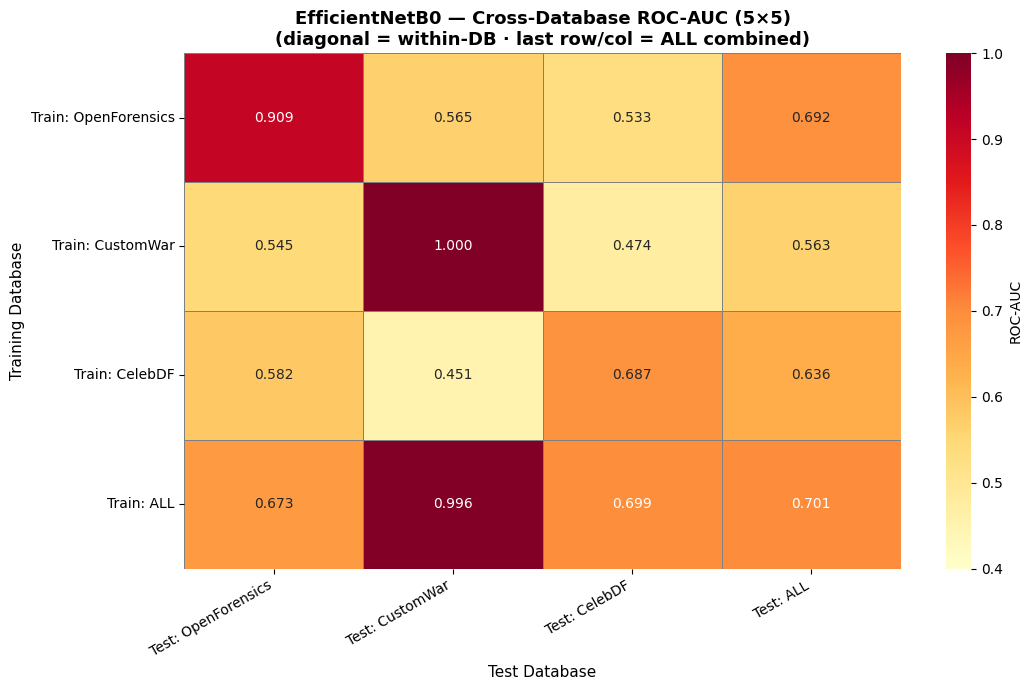

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/cross_db_roc_auc.png

ROC-AUC Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: ALL
Train: OpenForensics             0.908885         0.564526       0.532706   0.692460
Train: CustomWar                 0.545405         0.999839       0.473581   0.563267
Train: CelebDF                   0.582119         0.450927       0.686789   0.636337
Train: ALL                       0.673469         0.996481       0.698595   0.701072



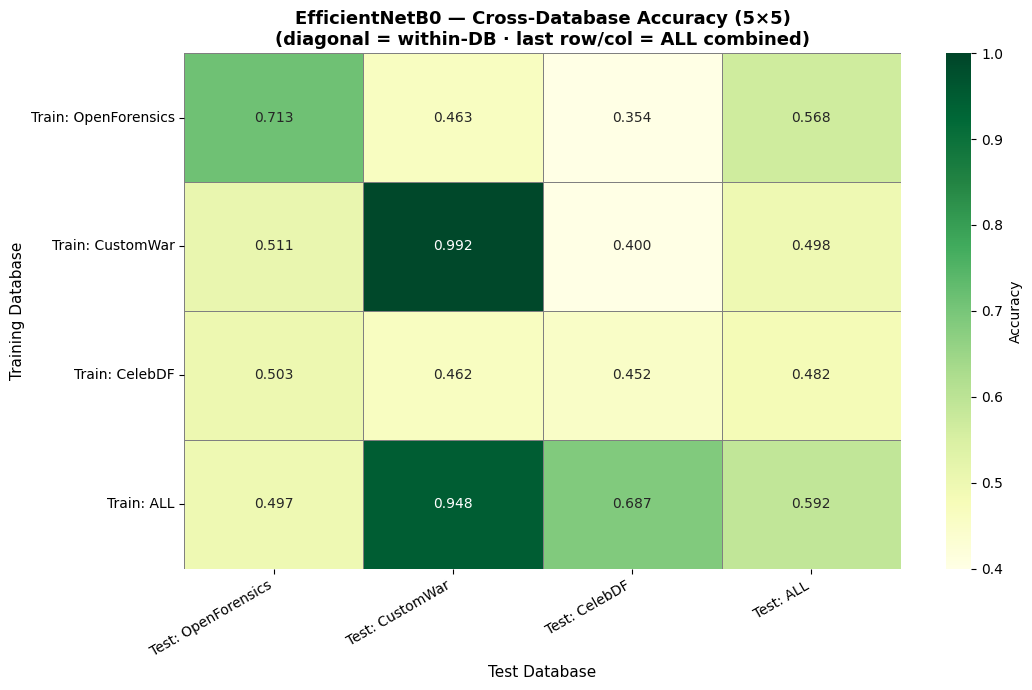

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/cross_db_accuracy.png

Accuracy Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: ALL
Train: OpenForensics             0.712884         0.462771       0.353891   0.567804
Train: CustomWar                 0.511417         0.992460       0.400145   0.497904
Train: CelebDF                   0.503072         0.461828       0.452364   0.482246
Train: ALL                       0.497203         0.948162       0.687273   0.591954



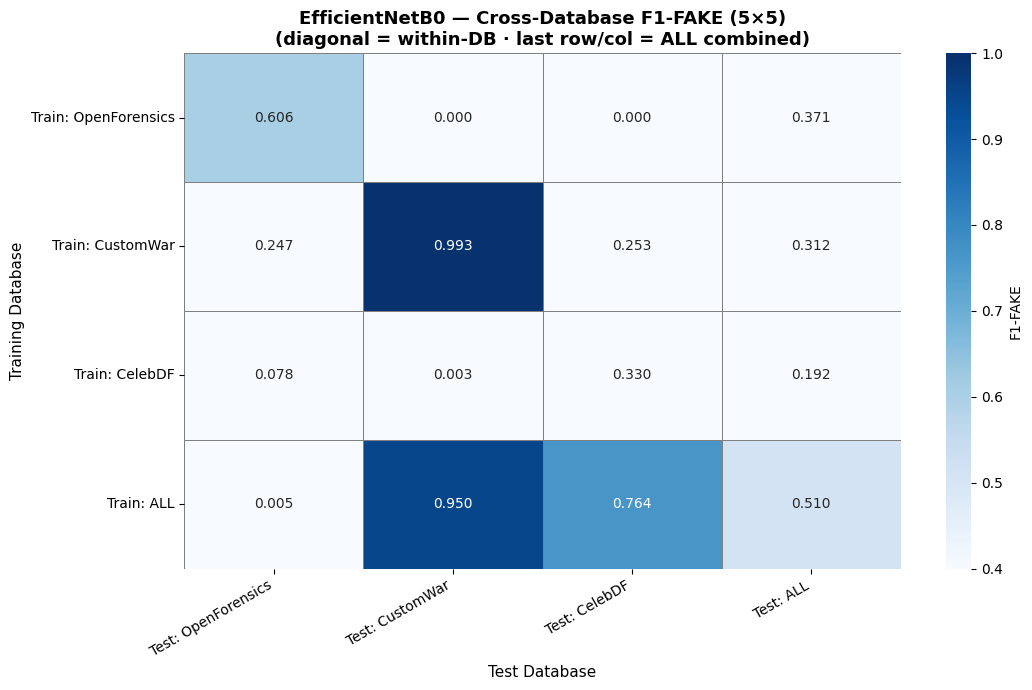

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/cross_db_f1_fake.png

F1-FAKE Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: ALL
Train: OpenForensics             0.605518         0.000000       0.000000   0.371148
Train: CustomWar                 0.246606         0.993019       0.253440   0.311599
Train: CelebDF                   0.078245         0.003490       0.330429   0.192133
Train: ALL                       0.005081         0.949680       0.763528   0.510194



In [9]:
# =================== CELL 9: CROSS-DATABASE RESULTS MATRIX (5×5) ===================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

axis_names = list(DATABASES.keys()) + ['ALL']

for metric_key, metric_label, cmap in [
    ('roc_auc',  'ROC-AUC',  'YlOrRd'),
    ('accuracy', 'Accuracy', 'YlGn'),
    ('f1_fake',  'F1-FAKE',  'Blues'),
]:
    available = [d for d in axis_names if d in all_results]
    matrix = [
        [all_results[tr].get(te, {}).get(metric_key, float('nan')) for te in axis_names]
        for tr in available
    ]
    df = pd.DataFrame(
        matrix,
        index=[f'Train: {d}' for d in available],
        columns=[f'Test: {d}' for d in axis_names]
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    sns.heatmap(
        df.astype(float), annot=True, fmt='.3f',
        cmap=cmap, vmin=0.40, vmax=1.00, ax=ax,
        linewidths=0.5, linecolor='gray',
        cbar_kws={'label': metric_label}
    )
    ax.set_title(
        f'EfficientNetB0 — Cross-Database {metric_label} (5×5)\n'
        '(diagonal = within-DB · last row/col = ALL combined)',
        fontsize=13, fontweight='bold'
    )
    ax.set_ylabel('Training Database', fontsize=11)
    ax.set_xlabel('Test Database',     fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'cross_db_{metric_key}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {fig_path}')
    print(f'\n{metric_label} Matrix:')
    print(df.to_string())
    print()

In [ ]:
# =================== CELL 10: ROC CURVES ===================
# One figure per training target (5 total).
# Each figure shows 5 ROC curves — one per test database.
# Within-DB curve is highlighted with a thicker solid line.
# ──────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve
import os

axis_names = list(DATABASES.keys()) + ['ALL']
TEST_COLORS = {
    db: c for db, c in zip(
        axis_names,
        ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
    )
}

for train_target in axis_names:
    if train_target not in all_preds:
        print(f'[SKIP] No predictions for train={train_target}')
        continue

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')

    for test_target in axis_names:
        if test_target not in all_preds.get(train_target, {}):
            continue
        y_true = np.array(all_preds[train_target][test_target]['y_true'])
        y_prob = np.array(all_preds[train_target][test_target]['y_prob'])
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val   = all_results[train_target][test_target]['roc_auc']
        is_within = (train_target == test_target)
        label     = f'{test_target}  (AUC={auc_val:.3f})'
        if is_within:
            label += '  ← within-DB'
        ax.plot(fpr, tpr,
                color=TEST_COLORS.get(test_target, 'gray'),
                lw=3.0 if is_within else 1.5,
                ls='-'  if is_within else '--',
                label=label)

    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate',  fontsize=12)
    ax.set_title(f'EfficientNetB0 — ROC Curves\nTrained on: {train_target}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'roc_curves_{train_target}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')
    print()

In [ ]:
# =================== CELL 11: CONFUSION MATRICES (5×5 GRID) ===================
# One confusion matrix per (train, test) pair — 25 total in a grid.
# Diagonal = within-DB (highlighted red title).
# ───────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import os

axis_names = list(DATABASES.keys()) + ['ALL']
n = len(axis_names)

fig, axes = plt.subplots(n, n, figsize=(4 * n, 3.5 * n))
fig.suptitle('EfficientNetB0 — Confusion Matrices (5×5)\nRows = Train DB · Cols = Test DB',
             fontsize=16, fontweight='bold', y=1.01)

for r, train_target in enumerate(axis_names):
    for c, test_target in enumerate(axis_names):
        ax = axes[r][c]
        if (train_target not in all_preds or
                test_target not in all_preds.get(train_target, {})):
            ax.axis('off')
            ax.set_title(f'Tr:{train_target}\nTe:{test_target}', fontsize=7)
            continue

        y_true = np.array(all_preds[train_target][test_target]['y_true'])
        y_pred = (np.array(all_preds[train_target][test_target]['y_prob']) >=
                  all_results[train_target][test_target].get('threshold', 0.5)).astype(int)
        cm      = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['REAL', 'FAKE'], fontsize=7)
        ax.set_yticks([0, 1]); ax.set_yticklabels(['REAL', 'FAKE'], fontsize=7)
        for i in range(2):
            for j in range(2):
                color = 'white' if cm_norm[i, j] > 0.6 else 'black'
                ax.text(j, i, str(cm[i, j]),
                        ha='center', va='center',
                        fontsize=9, fontweight='bold', color=color)
        is_within = (train_target == test_target)
        ax.set_title(f'Tr:{train_target} → Te:{test_target}',
                     fontsize=7,
                     color='#cc0000' if is_within else 'black',
                     fontweight='bold' if is_within else 'normal')
        ax.set_ylabel('True', fontsize=6); ax.set_xlabel('Pred', fontsize=6)

plt.tight_layout()
cm_path = os.path.join(MODEL_DIR, 'confusion_matrices_5x5.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

In [ ]:
# =================== CELL 12: PER-CLASS METRICS BAR CHART ===================
# For each training target: grouped bars showing Precision, Recall, F1 FAKE,
# F1 REAL, ROC-AUC, Accuracy across all test databases.
# Within-DB group highlighted in yellow.
# ──────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
import os

axis_names = list(DATABASES.keys()) + ['ALL']

METRICS = [
    ('precision_fake', 'Prec-FAKE',  '#e6194b'),
    ('recall_fake',    'Rec-FAKE',   '#f58231'),
    ('f1_fake',        'F1-FAKE',    '#3cb44b'),
    ('f1_real',        'F1-REAL',    '#4363d8'),
    ('roc_auc',        'ROC-AUC',    '#911eb4'),
    ('accuracy',       'Accuracy',   '#42d4f4'),
]

for train_target in axis_names:
    if train_target not in all_results:
        continue
    test_dbs  = [t for t in axis_names if t in all_results[train_target]]
    n_tests   = len(test_dbs)
    n_metrics = len(METRICS)
    x         = np.arange(n_tests)
    bar_w     = 0.13
    offsets   = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_w

    fig, ax = plt.subplots(figsize=(max(10, n_tests * 2), 6))

    for i, (key, label, color) in enumerate(METRICS):
        values = [all_results[train_target][t].get(key, float('nan')) for t in test_dbs]
        bars   = ax.bar(x + offsets[i], values, bar_w,
                        label=label, color=color, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{val:.2f}', ha='center', va='bottom',
                        fontsize=6, rotation=90)

    ax.set_xticks(x); ax.set_xticklabels(test_dbs, fontsize=10)
    ax.set_ylim(0, 1.20)
    ax.set_ylabel('Score', fontsize=11); ax.set_xlabel('Test Database', fontsize=11)
    ax.set_title(f'EfficientNetB0 — Per-Class Metrics\nTrained on: {train_target}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    if train_target in test_dbs:
        idx = test_dbs.index(train_target)
        ax.axvspan(idx - 0.45, idx + 0.45, color='yellow', alpha=0.15)
        ax.text(idx, 1.15, 'within-DB', ha='center', fontsize=8,
                color='#888800', fontstyle='italic')

    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'per_class_metrics_{train_target}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')
    print()

In [ ]:
# =================== FINAL GOOGLE DRIVE SYNC ===================
# Syncs ALL models, results (.pkl), CSV, and visualisation PNGs
# to Google Drive.  Runs after visualisations so every PNG is included.
# ────────────────────────────────────────────────────────────────

import subprocess

gdrive_dest  = 'gdrive:deepfake_image_project/models/RealEyes_experiment/efficientnet'
print(f'Syncing {MODEL_DIR}')
print(f'     to {gdrive_dest} ...')

result = subprocess.run(
    ['rclone', 'sync', MODEL_DIR, gdrive_dest, '--progress', '--stats-one-line'],
    capture_output=False, text=True
)
if result.returncode == 0:
    print(f'\nGoogle Drive sync complete.')
    print(f'  All models, results, and visualisations are now on Drive.')
else:
    print(f'\nWARNING: rclone sync failed (exit {result.returncode}).')
    print(f'  Files are safe locally at {MODEL_DIR}')

In [10]:
# =================== CELL 10: SAVE RESULTS TABLE ===================

import pandas as pd

rows = []
for train_db, test_map in all_results.items():
    for test_db, metrics in test_map.items():
        rows.append({
            'model':    'efficientnet_b0',
            'train_db': train_db,
            'test_db':  test_db,
            **metrics,
        })

results_df = pd.DataFrame(rows)
csv_path   = os.path.join(MODEL_DIR, 'cross_db_results.csv')
results_df.to_csv(csv_path, index=False)

print('Results saved to:', csv_path)
print(f'Total rows: {len(results_df)}  (expected 25 for full 5×5)')
display(results_df)

Results saved to: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/cross_db_results.csv
Total rows: 16  (expected 25 for full 5×5)


,model,train_db,test_db,accuracy,roc_auc,f1_fake,f1_real,precision_fake,recall_fake
0,efficientnet_b0,OpenForensics,OpenForensics,0.712884,0.908885,0.605518,0.774310,0.982822,0.437546
1,efficientnet_b0,OpenForensics,CustomWar,0.462771,0.564526,0.000000,0.632732,0.000000,0.000000
2,efficientnet_b0,OpenForensics,CelebDF,0.353891,0.532706,0.000000,0.522776,0.000000,0.000000
3,efficientnet_b0,OpenForensics,ALL,0.567804,0.692460,0.371148,0.670764,0.982822,0.228770
4,efficientnet_b0,CustomWar,OpenForensics,0.511417,0.545405,0.246606,0.638486,0.551899,0.158776
5,efficientnet_b0,CustomWar,CustomWar,0.992460,0.999839,0.993019,0.991803,0.987847,0.998246
6,efficientnet_b0,CustomWar,CelebDF,0.400145,0.473581,0.253440,0.498663,0.646950,0.157587
7,efficientnet_b0,CustomWar,ALL,0.497904,0.563267,0.311599,0.604845,0.661211,0.203827
8,efficientnet_b0,CelebDF,OpenForensics,0.503072,0.582119,0.078245,0.659846,0.594315,0.041879
9,efficientnet_b0,CelebDF,CustomWar,0.461828,0.450927,0.003490,0.631375,0.333333,0.001754


In [11]:
# =================== CELL 11: TENSORBOARD LAUNCH INSTRUCTIONS ===================

print('-' * 60)
print('  TENSORBOARD DASHBOARD')
print('-' * 60)
print()
print('1. On the SERVER terminal:')
print(f'   tensorboard --logdir {TB_LOG_ROOT} --port 6006 --bind_all')
print()
print('2. On your LOCAL machine, open an SSH tunnel:')
print('   ssh -L 6006:localhost:6006 <your_user>@<server_ip>')
print()
print('3. Open in browser:  http://localhost:6006')
print()
print('TensorBoard log structure (now includes ALL run):')
print(f'  {TB_LOG_ROOT}/')
print(f'  └── {MODEL_NAME}/')
print(f'      ├── train_OpenForensics/')
print(f'      ├── train_CustomWar/')
print(f'      ├── train_CelebDF/')
print(f'      ├── train_CiFake/')
print(f'      ├── train_ALL/')
print(f'      └── cross_db_eval/')
print(f'          ├── train_OpenForensics__test_CustomWar/')
print(f'          ├── train_OpenForensics__test_ALL/')
print(f'          ├── train_ALL__test_OpenForensics/')
print(f'          └── ... (25 train→test pairs)')

------------------------------------------------------------
  TENSORBOARD DASHBOARD
------------------------------------------------------------

1. On the SERVER terminal:
   tensorboard --logdir /home/sceuser/RealEyes/tensorboard_logs --port 6006 --bind_all

2. On your LOCAL machine, open an SSH tunnel:
   ssh -L 6006:localhost:6006 <your_user>@<server_ip>

3. Open in browser:  http://localhost:6006

TensorBoard log structure (now includes ALL run):
  /home/sceuser/RealEyes/tensorboard_logs/
  └── efficientnet/
      ├── train_OpenForensics/
      ├── train_CustomWar/
      ├── train_CelebDF/
      ├── train_CiFake/
      ├── train_ALL/
      └── cross_db_eval/
          ├── train_OpenForensics__test_CustomWar/
          ├── train_OpenForensics__test_ALL/
          ├── train_ALL__test_OpenForensics/
          └── ... (25 train→test pairs)
